# Backtest selection: record the candidates that lost

Allocation choices such as lookback length, covariance shrinkage, eligible assets and defensive thresholds create a search space. A winning backtest does not describe that search. Here a complete, fixed library has **zero population skill by construction**, so we can inspect what selection alone produces.

We calculate CSCV ranks and the original 2014 PSR/DSR, then compare the selected candidate with a separate set of independent observations. These are original synthetic performance series, not ETF strategies or an empirical certificate for the project's historical case study. [Chapter discussion](README.md) · [Research map](../../README.md)

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "research/validation.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})
import hashlib
from scipy.stats import skew, kurtosis, norm
from research.validation import (
    sharpe_ratio, cscv_diagnostics, probabilistic_sharpe_ratio,
    expected_maximum_sharpe, deflated_sharpe_ratio,
)

SEED, N_CANDIDATES, OBSERVATIONS, BLOCKS = 20260919, 128, 504, 8
candidate_ids = [f"null_{i:03d}" for i in range(N_CANDIDATES)]
rng = np.random.default_rng(SEED)
selection_returns = rng.normal(0, 0.01, (OBSERVATIONS, N_CANDIDATES))
independent_returns = rng.normal(0, 0.01, (OBSERVATIONS, N_CANDIDATES))
# The second matrix uses independent subsequent draws; it does not influence selection.
train_sharpes = sharpe_ratio(selection_returns)
selected = int(np.argmax(train_sharpes))
selected_returns = selection_returns[:, selected]
independent_sharpes = sharpe_ratio(independent_returns)
annual_scale = np.sqrt(252)  # Display convention only: inference below uses daily units.

library_design = {
    "seed": SEED, "generator": "NumPy default_rng / PCG64",
    "candidates": N_CANDIDATES, "observations_per_matrix": OBSERVATIONS,
    "population_daily_mean": 0.0, "population_daily_standard_deviation": 0.01,
    "construction": "IID Normal across dates, candidates and the two matrices",
    "candidate_ids": candidate_ids,
    "selection_matrix_sha256_float64_little_endian_C_order": hashlib.sha256(
        selection_returns.astype("<f8").tobytes()).hexdigest(),
    "independent_matrix_sha256_float64_little_endian_C_order": hashlib.sha256(
        independent_returns.astype("<f8").tobytes()).hexdigest(),
}
print(library_design)
ledger = pd.DataFrame({"candidate": candidate_ids,
    "selection_SR_annualized": train_sharpes * annual_scale,
    "independent_SR_annualized": independent_sharpes * annual_scale})
assert len(ledger) == N_CANDIDATES and ledger.candidate.is_unique
print(f"Selected by training Sharpe only: {candidate_ids[selected]}")
display(ledger.iloc[[selected]])

{'seed': 20260919, 'generator': 'NumPy default_rng / PCG64', 'candidates': 128, 'observations_per_matrix': 504, 'population_daily_mean': 0.0, 'population_daily_standard_deviation': 0.01, 'construction': 'IID Normal across dates, candidates and the two matrices', 'candidate_ids': ['null_000', 'null_001', 'null_002', 'null_003', 'null_004', 'null_005', 'null_006', 'null_007', 'null_008', 'null_009', 'null_010', 'null_011', 'null_012', 'null_013', 'null_014', 'null_015', 'null_016', 'null_017', 'null_018', 'null_019', 'null_020', 'null_021', 'null_022', 'null_023', 'null_024', 'null_025', 'null_026', 'null_027', 'null_028', 'null_029', 'null_030', 'null_031', 'null_032', 'null_033', 'null_034', 'null_035', 'null_036', 'null_037', 'null_038', 'null_039', 'null_040', 'null_041', 'null_042', 'null_043', 'null_044', 'null_045', 'null_046', 'null_047', 'null_048', 'null_049', 'null_050', 'null_051', 'null_052', 'null_053', 'null_054', 'null_055', 'null_056', 'null_057', 'null_058', 'null_059',

,candidate,selection_SR_annualized,independent_SR_annualized
72,null_072,2.004295,0.220371


## Recombine blocks without calling them new market histories

CSCV splits the selection sample into eight contiguous blocks and evaluates all 70 ways to choose four training blocks, using their complements for testing. Selection and scoring always use different rows within each split. The original independent matrix above stays outside CSCV.

Out-of-sample ranks ascend from worst to best. With $N$ candidates, the relative rank is $r/(N+1)$ and the logit is $\log[p/(1-p)]$. Average ranks handle test ties; the first declared column wins an exact training tie. We report the fraction with logit $\leq0$, including the median boundary. Duplicate identical candidates have logit zero and offer no ranking information.

These reused splits are not independent trials, not CPCV, and not a sequence of investable out-of-sample returns. The reported fraction describes the fixed candidate library under this partition choice; no binomial confidence interval is attached.

In [2]:
diagnostics = cscv_diagnostics(selection_returns, n_blocks=BLOCKS)
assert len(diagnostics) == 70
pbo = float((diagnostics.logit <= 0).mean())
# An independent count-based rank check for one split, including ties.
first = diagnostics.iloc[0]
block_indices = np.split(np.arange(OBSERVATIONS), BLOCKS)
held_out_indices = np.concatenate([block_indices[i] for i in range(BLOCKS)
                                  if i not in first.training_blocks])
test_scores = sharpe_ratio(selection_returns[held_out_indices])
winner_score = test_scores[int(first.selected)]
manual_rank = (test_scores < winner_score).sum() + ((test_scores == winner_score).sum() + 1) / 2
assert np.isclose(first.relative_rank, manual_rank / (N_CANDIDATES + 1))
assert np.isclose(first.logit, np.log(manual_rank / (N_CANDIDATES + 1 - manual_rank)))
print(f"CSCV at-or-below-median fraction: {pbo:.4f} across {len(diagnostics)} reused splits")
display(diagnostics.head(8))

CSCV at-or-below-median fraction: 0.3143 across 70 reused splits


,training_blocks,selected,in_sample_sharpe,out_of_sample_sharpe,relative_rank,logit
0,"(0, 1, 2, 3)",24,0.195765,-0.020408,0.364341,-0.556572
1,"(0, 1, 2, 4)",41,0.178258,0.030367,0.713178,0.910871
2,"(0, 1, 2, 5)",11,0.165259,-0.005128,0.465116,-0.139762
3,"(0, 1, 2, 6)",43,0.175251,0.010245,0.542636,0.170958
4,"(0, 1, 2, 7)",11,0.156093,0.006180,0.511628,0.046520
5,"(0, 1, 3, 4)",11,0.169261,-0.015506,0.434109,-0.265108
6,"(0, 1, 3, 5)",11,0.159341,-0.005683,0.449612,-0.202237
7,"(0, 1, 3, 6)",11,0.166485,-0.009377,0.441860,-0.233615


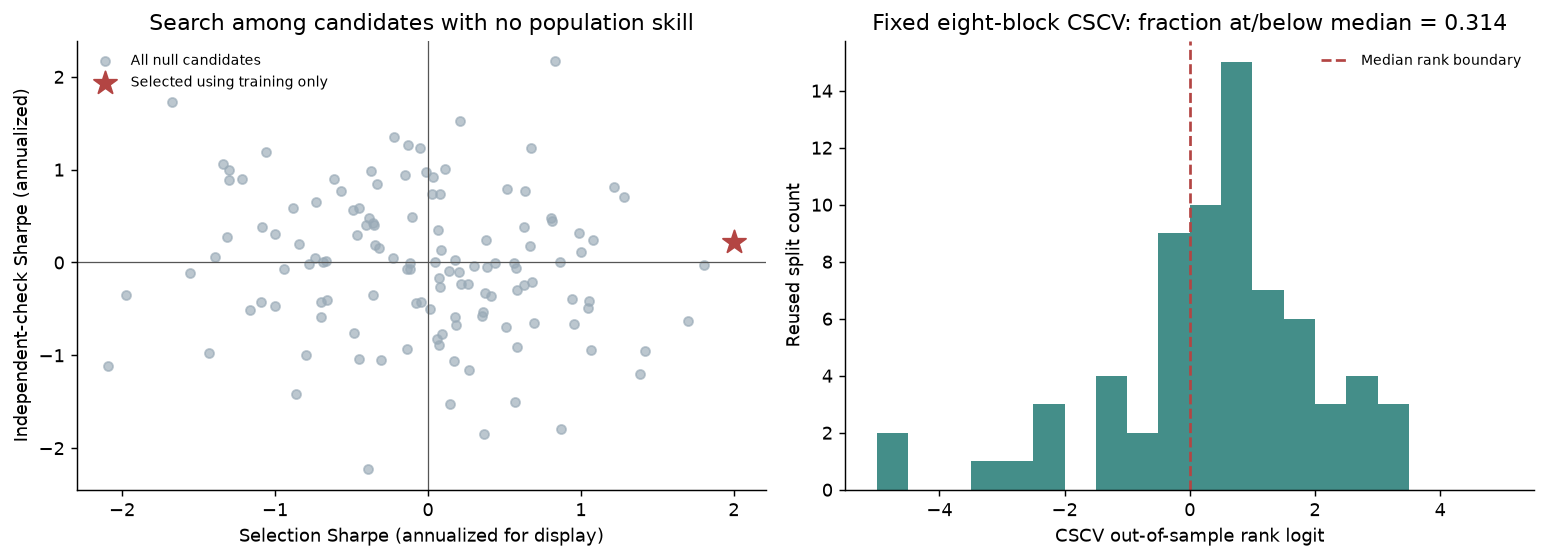

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
axes[0].scatter(train_sharpes * annual_scale, independent_sharpes * annual_scale,
                color="#98a9b6", alpha=0.65, s=25, label="All null candidates")
axes[0].scatter(train_sharpes[selected] * annual_scale,
                independent_sharpes[selected] * annual_scale,
                color="#b34543", marker="*", s=180, label="Selected using training only")
axes[0].axhline(0, color="#555555", linewidth=0.7)
axes[0].axvline(0, color="#555555", linewidth=0.7)
axes[0].set(xlabel="Selection Sharpe (annualized for display)",
            ylabel="Independent-check Sharpe (annualized)", title="Search among candidates with no population skill")
axes[0].legend(frameon=False, fontsize=8)
axes[1].hist(diagnostics.logit, bins=np.linspace(-5, 5, 21), color="#237a75", alpha=0.85)
axes[1].axvline(0, color="#b34543", linestyle="--", label="Median rank boundary")
axes[1].set(xlabel="CSCV out-of-sample rank logit", ylabel="Reused split count",
            title=f"Fixed eight-block CSCV: fraction at/below median = {pbo:.3f}")
axes[1].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

## Adjust the benchmark for the disclosed search

For observed **daily** Sharpe $widehat{SR}$, sample size $T$, skewness $gamma_3$ and Pearson kurtosis $gamma_4$, the PSR statistic is

$$Phi!left[rac{(widehat{SR}-SR_0)sqrt{T-1}}{sqrt{1-gamma_3widehat{SR}+(gamma_4-1)widehat{SR}^2/4}}
ight].$$

The original 2014 DSR sets $SR_0$ to an approximation of the expected maximum of $N$ independent, zero-mean Normal trial Sharpe estimates. With their cross-trial standard deviation $s_{SR}$ and Euler's constant $gamma$, the benchmark for $N>1$ is

$$s_{SR}left[(1-gamma)Phi^{-1}(1-1/N)+gammaPhi^{-1}(1-1/(Ne))
ight].$$

For one trial its expected maximum is exactly zero. The approximation concerns **Sharpe estimates across candidates**; its input is not the daily volatility of the selected portfolio. The displayed sample skewness and non-excess kurtosis use SciPy's bias-corrected moment estimates. These asymptotic statistics assume independent observations here and do not represent posterior probabilities of skill.

In [4]:
observed = float(train_sharpes[selected])
trial_spread = float(train_sharpes.std(ddof=1))
selected_skew = float(skew(selected_returns, bias=False))
selected_kurtosis = float(kurtosis(selected_returns, fisher=False, bias=False))
psr = probabilistic_sharpe_ratio(observed, OBSERVATIONS,
    skewness=selected_skew, kurtosis=selected_kurtosis)
threshold = expected_maximum_sharpe(trial_spread, N_CANDIDATES)
dsr = deflated_sharpe_ratio(observed, OBSERVATIONS, trial_spread, N_CANDIDATES,
    skewness=selected_skew, kurtosis=selected_kurtosis)
manual_se = np.sqrt((1 - selected_skew * observed
    + (selected_kurtosis - 1) * observed**2 / 4) / (OBSERVATIONS - 1))
assert np.isclose(dsr, norm.cdf((observed - threshold) / manual_se))
assert np.isclose(deflated_sharpe_ratio(observed, OBSERVATIONS, trial_spread, 1,
    skewness=selected_skew, kurtosis=selected_kurtosis), psr)
assert dsr <= psr

display(pd.Series({"daily Sharpe selected": observed,
    "cross-trial daily Sharpe standard deviation": trial_spread,
    "selected sample skewness": selected_skew,
    "selected sample non-excess kurtosis": selected_kurtosis,
    "daily expected-max benchmark for 128 trials": threshold,
    "PSR versus zero": psr, "2014 DSR with declared 128 trials": dsr}, name="Constructed example"))

# Counterfactual disclosure sensitivity: the same observed sample and spread,
# changing only the assumed trial count. Actual constructed library size is 128.
trial_counts = [1, 8, 32, 128, 512]
sensitivity = pd.DataFrame({"assumed independent trials": trial_counts,
    "2014 DSR": [deflated_sharpe_ratio(observed, OBSERVATIONS, trial_spread, n,
        skewness=selected_skew, kurtosis=selected_kurtosis) for n in trial_counts]})
assert np.all(np.diff(sensitivity["2014 DSR"]) < 0)
display(sensitivity)

daily Sharpe selected                          0.126259
cross-trial daily Sharpe standard deviation    0.049913
selected sample skewness                       0.186958
selected sample non-excess kurtosis            3.308793
daily expected-max benchmark for 128 trials    0.130585
PSR versus zero                                0.997830
2014 DSR with declared 128 trials              0.461074
Name: Constructed example, dtype: float64

,assumed independent trials,2014 DSR
0,1,0.997830
1,8,0.886315
2,32,0.686002
3,128,0.461074
4,512,0.275029


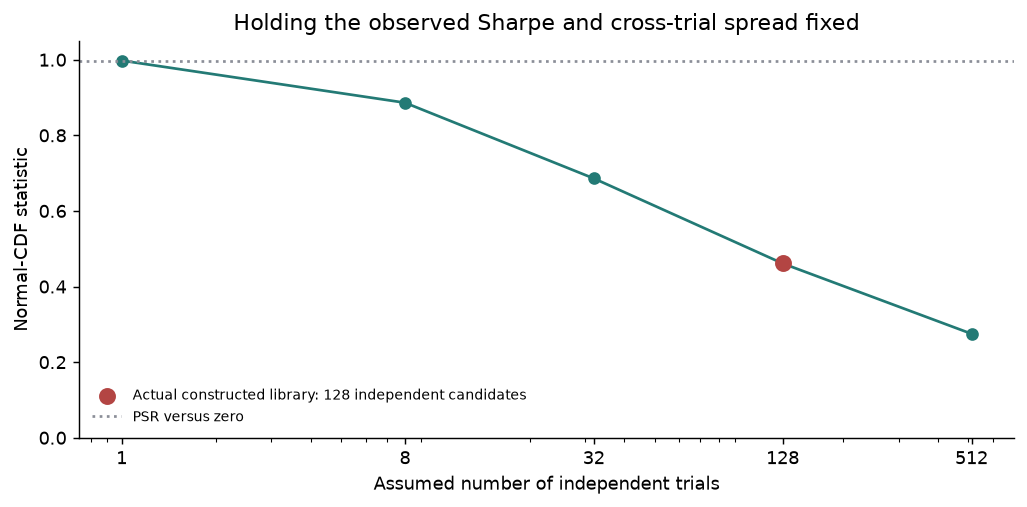

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(trial_counts, sensitivity["2014 DSR"], marker="o", color="#237a75")
ax.scatter([N_CANDIDATES], [dsr], color="#b34543", s=70, zorder=3,
            label="Actual constructed library: 128 independent candidates")
ax.axhline(psr, color="#8b8e98", linestyle=":", label="PSR versus zero")
ax.set_xscale("log")
ax.set_xticks(trial_counts, labels=trial_counts)
ax.set(ylim=(0, 1.05), xlabel="Assumed number of independent trials",
       ylabel="Normal-CDF statistic", title="Holding the observed Sharpe and cross-trial spread fixed")
ax.legend(frameon=False, fontsize=8, loc="lower left")
fig.tight_layout()
plt.show()

## What the example supports

The selected candidate's training Sharpe, independent-check Sharpe, DSR and CSCV ranks answer different questions. Their values need not agree on a single verdict. We know the entire population has zero skill because we constructed it that way; a favorable finite-sample rank or statistic cannot change that fact. A fresh random draw may also look attractive by chance. Repeatedly regenerating examples until the independent check looks good would itself be additional selection.

For asset allocation, keep every attempted lookback, universe, estimator, constraint and signal rule in the trial ledger. Specify the economic premise and selection metric before the search. An independent future evaluation must remain outside that selection process; changing the rule after inspecting it consumes that evaluation.

The independent candidates used here are convenient for examining the 2014 approximation. Real portfolio variants often share assets and dates. Their raw candidate count is not automatically the effective independent trial count, and serial correlation or overlapping returns invalidate the simple observation-count standard error. The counterfactual table does not estimate either dependency correction. This chapter does not implement the later unified DSR framework or full CPCV.

The project's ETF history is retrospective and its full earlier search record is unavailable. **No empirical DSR or PBO claim is attached to that case study.** Nor can these diagnostics repair missing trials, a weak economic hypothesis or structural change.

Primary references: [Bailey and López de Prado (2014), *The Deflated Sharpe Ratio*](https://www.davidhbailey.com/dhbpapers/deflated-sharpe.pdf); [Bailey, Borwein, López de Prado and Zhu, *The Probability of Backtest Overfitting*](https://www.davidhbailey.com/dhbpapers/backtest-prob.pdf). Original implementation: [research/validation.py](../../research/validation.py).